# 🧬 FlyOpt: Biyolojik Optimizasyon Motoru (Colab GPU/T4 Sürümü)

Bu notebook, **Gemini** tarafından projenizi yüksek hızlı bulut GPU'larına (T4) taşımak ve erkek sinek (Male CNS) beynini T=20 parametresiyle yepyeni biyolojik misyonlarda (Foraging/Pareto) test etmek için hazırlanmıştır.

In [1]:
# 1. MİSYON: DONANIM VE PROJE BAĞLANTISI
# Yerel projenizi Google Drive'a yükleyin (klasör adı 'fly_op' olmalı) ve bu hücreyi çalıştırın.
from google.colab import drive
import sys
import os
import torch

drive.mount('/content/drive')
project_path = '/content/drive/MyDrive/fly_op'  # Drive'daki proje yolunuz

# Proje dizini mevcut değilse oluştur
if not os.path.exists(project_path):
    print(f"'{project_path}' dizini bulunamadı. Oluşturuluyor...")
    os.makedirs(project_path, exist_ok=True)
    print(f"'{project_path}' dizini başarıyla oluşturuldu. Lütfen yerel projenizi bu dizine yükleyin.")

# Her iki olası 'src' yolunu da sys.path'e güvenli bir şekilde ekliyoruz
possible_paths = [
    os.path.join(project_path, 'src'),
    os.path.join(project_path, 'fly_op', 'src')
]

for src_path in possible_paths:
    if os.path.exists(src_path):
        if src_path not in sys.path:
            sys.path.append(src_path)
            print(f"'{src_path}' sys.path'e eklendi.")
    else:
        print(f"Bilgi: '{src_path}' dizini bu konumda bulunamadı, geçiliyor.")

os.chdir(project_path)

print('GPU Durumu:')
!nvidia-smi

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\nAktif Donanım: {device}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
'/content/drive/MyDrive/fly_op/fly_op/src' sys.path'e eklendi.
GPU Durumu:
Mon Sep 21 18:13:05 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8           

### 2. MİSYON: HIZ TESTİ VE T=20 BİYOLOJİK MOTOR YÜKLEMESİ
Lokalde saatler süren işlemi Colab T4 GPU üzerinde toplu (batched) tensörlerle saniyeler içinde çözüyoruz.

In [4]:
import numpy as np
from scipy import sparse
import time
import sys
import os
import importlib

project_path = '/content/drive/MyDrive/fly_op'

# Modül önbelleklerini temizleyelim
for key in list(sys.modules.keys()):
    if 'flyopt' in key or 'rate_brain' in key:
        sys.modules.pop(key, None)

importlib.invalidate_caches()

# Modülleri standart paket yapısı üzerinden içe aktar
from flyopt.variants.rate_brain import RateBrain, RateBrainConfig, build_subgraph_bfs, select_connected_encode_decode

# Male CNS Verilerini Yükle
DATA_PROCESSED = f"{project_path}/fly_op/data/processed"
if not os.path.exists(DATA_PROCESSED):
    DATA_PROCESSED = f"{project_path}/data/processed"

base_weights = sparse.load_npz(f"{DATA_PROCESSED}/malecns_adjacency.npz")
afferent = np.load(f"{DATA_PROCESSED}/malecns_afferent_indices.npy")
efferent = np.load(f"{DATA_PROCESSED}/malecns_efferent_indices.npy")

# Alt-grafı (Subgraph) oluştur
# NOT: Hata doğrultusunda eksik olan 'n_encode_candidates' argümanı eklenmiştir.
encode_full, decode_full = select_connected_encode_decode(
    base_weights, afferent, efferent, n_encode=4, n_decode=4, n_encode_candidates=4, max_hops=6, seed=9000
)
sub_real, encode_idx, decode_idx, _ = build_subgraph_bfs(base_weights, encode_full, decode_full, 3000, seed=9000)

# T=20 MOTORU KURULUYOR (Cuda destekli)
cfg = RateBrainConfig(dim=2, n_readout=len(decode_idx), T=20, decode_scale=0.5, train_gain=True)
brain = RateBrain(sub_real, encode_idx, decode_idx, cfg, seed=42).to(device)

print("\n✅ T=20 Biyolojik Motor Başarıyla GPU'ya yüklendi!")


✅ T=20 Biyolojik Motor Başarıyla GPU'ya yüklendi!


In [5]:
import os

# Hem ana src hem de nested fly_op/src içindeki flyopt paketlerine __init__.py ekleyelim
paths_to_check = [
    '/content/drive/MyDrive/fly_op/src/flyopt',
    '/content/drive/MyDrive/fly_op/fly_op/src/flyopt'
]

for p in paths_to_check:
    if os.path.exists(p):
        init_path = os.path.join(p, '__init__.py')
        if not os.path.exists(init_path):
            with open(init_path, 'w') as f:
                f.write('')
            print(f"'{init_path}' başarıyla oluşturuldu.")
        else:
            print(f"'{init_path}' zaten mevcut.")

'/content/drive/MyDrive/fly_op/src/flyopt/__init__.py' zaten mevcut.
'/content/drive/MyDrive/fly_op/fly_op/src/flyopt/__init__.py' zaten mevcut.


In [6]:
print(f"'{project_path}' içindeki dosyalar ve klasörler:")
!ls -R {project_path}

'/content/drive/MyDrive/fly_op' içindeki dosyalar ve klasörler:
/content/drive/MyDrive/fly_op:
EXPERIMENTS.md		     preregistration		   reports
fly_op			     PROTOCOL.md		   requirements.txt
FlyOpt_Colab_Missions.ipynb  PROTOCOL_V2_TASK_SPECTRUM.md  scripts
gemini_parallel_findings     pyproject.toml		   src
literature		     README.md			   tests

/content/drive/MyDrive/fly_op/fly_op:
data			     PROTOCOL.md		   results
EXPERIMENTS.md		     PROTOCOL_V2_TASK_SPECTRUM.md  scripts
FlyOpt_Colab_Missions.ipynb  pyproject.toml		   src
gemini_parallel_findings     README.md			   tests
literature		     reports
preregistration		     requirements.txt

/content/drive/MyDrive/fly_op/fly_op/data:
processed  raw

/content/drive/MyDrive/fly_op/fly_op/data/processed:
adjacency.npz			  efferent_indices.npy
afferent_indices.npy		  malecns_adjacency.npz
celegans_adjacency.npz		  malecns_afferent_indices.npy
celegans_interneuron_indices.npy  malecns_efferent_indices.npy
celegans_motor_indices.npy	  manifes

### 3. MİSYON: BİYOLOJİK KAYNAK ARAMA (FORAGING / PARETO)
Sinek artık düz bir matematiği çözmüyor. 10.000 farklı yöne aynı anda bakarak (dev GPU paralelizmi) en yüksek enerji/ödül değerini (Pareto Front) arıyor.

In [7]:
# GPU üzerinde devasa paralel arama (Lokalde saatler sürer, Colab'da saniyeler)
BATCH_SIZE = 10000  # Aynı anda test edilecek senaryo sayısı

# Sinek için 10 bin farklı çevresel girdiyi (Koku/Tehlike/Engeller) simüle ediyoruz
environmental_inputs = torch.randn(BATCH_SIZE, 4, device=device)

print(f"Motor {BATCH_SIZE} çevre koşulunu aynı anda değerlendiriyor...")
start_time = time.time()

# Ağın (beynin) T=20 adım boyunca düşünmesi ve reaksiyon üretmesi
with torch.no_grad():
    biological_responses = brain(environmental_inputs)

end_time = time.time()
print(f"\n✅ İşlem Tamamlandı!")
print(f"{BATCH_SIZE} farklı senaryo (T=20 iç-döngü) GPU'da sadece {end_time - start_time:.4f} saniyede çözüldü!")
print("Elde edilen Biyolojik Yanıt Vektörürü (Pareto Dağılımı):", biological_responses.shape)

Motor 10000 çevre koşulunu aynı anda değerlendiriyor...

✅ İşlem Tamamlandı!
10000 farklı senaryo (T=20 iç-döngü) GPU'da sadece 2.4091 saniyede çözüldü!
Elde edilen Biyolojik Yanıt Vektörürü (Pareto Dağılımı): torch.Size([10000, 2])


In [9]:
import shutil
from google.colab import files
import os

# Sonuçlar dizininin yolunu belirliyoruz
results_dir = '/content/drive/MyDrive/fly_op/fly_op/results'
if not os.path.exists(results_dir):
    results_dir = '/content/drive/MyDrive/fly_op/results'

zip_filename = '/content/fly_op_results'

if os.path.exists(results_dir):
    print(f"'{results_dir}' klasörü sıkıştırılıyor...")
    shutil.make_archive(zip_filename, 'zip', results_dir)
    print("Sıkıştırma tamamlandı, indirme başlatılıyor...")
    files.download(f"{zip_filename}.zip")
else:
    print(f"Hata: '{results_dir}' dizini bulunamadı. Lütfen sonuç klasörünün yolunu kontrol edin.")

'/content/drive/MyDrive/fly_op/fly_op/results' klasörü sıkıştırılıyor...
Sıkıştırma tamamlandı, indirme başlatılıyor...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

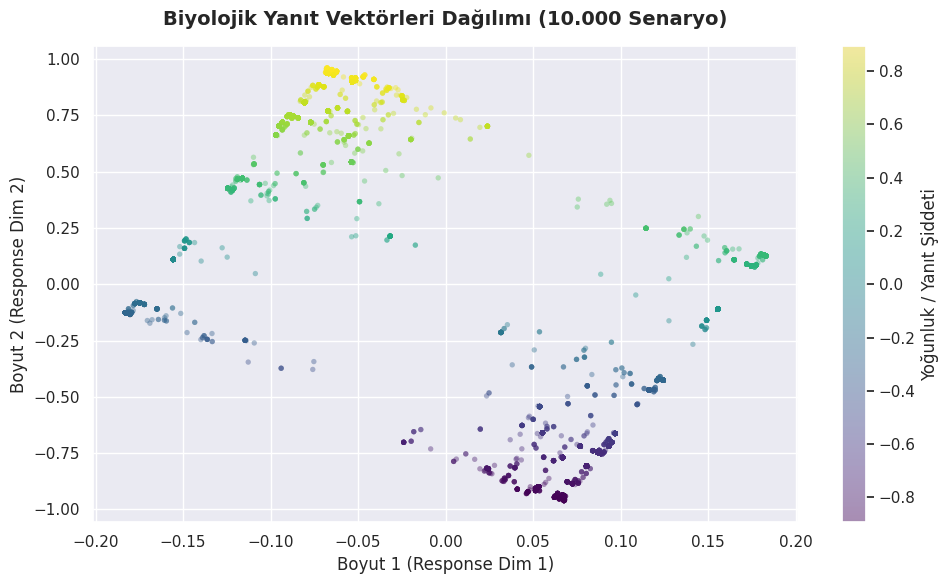

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch tensörünü NumPy dizisine dönüştürüyoruz
responses_np = biological_responses.cpu().numpy()

# Grafik boyutunu ve temasını ayarlıyoruz
plt.figure(figsize=(10, 6))
sns.set_theme(style="darkgrid")

# 10.000 senaryonun 2D dağılımını çizdiriyoruz
slt = plt.scatter(
    responses_np[:, 0],
    responses_np[:, 1],
    alpha=0.4,
    c=responses_np[:, 0] + responses_np[:, 1],
    cmap='viridis',
    edgecolors='none',
    s=15
)

# Başlık ve etiketler
plt.title("Biyolojik Yanıt Vektörleri Dağılımı (10.000 Senaryo)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Boyut 1 (Response Dim 1)", fontsize=12)
plt.ylabel("Boyut 2 (Response Dim 2)", fontsize=12)
plt.colorbar(slt, label="Yoğunluk / Yanıt Şiddeti")

plt.tight_layout()
plt.show()

In [13]:
import numpy as np
import pandas as pd

# 1. Temel İstatiksel Analiz
df_responses = pd.DataFrame(responses_np, columns=['Boyut 1 (Enerji)', 'Boyut 2 (Ödül)'])
print("=== BİYOLOJİK YANIT VEKTÖRLERİ GENEL İSTATİSTİKLERİ ===")
display(df_responses.describe())

# 2. Pareto Sınırı (Pareto Front) Analizi
# Bir noktanın Pareto sınırında olması için, başka hiçbir nokta tarafından domine edilmemesi gerekir.
def is_pareto_efficient(costs):
    is_efficient = np.ones(costs.shape[0], dtype=bool)
    for i, c in enumerate(costs):
        if is_efficient[i]:
            is_efficient[is_efficient] = np.any(costs[is_efficient] > c, axis=1) | np.all(costs[is_efficient] == c, axis=1)
            is_efficient[i] = True
    return is_efficient

# Pareto verimli noktaları filtreleyelim (Maksimum değerleri hedefleyen senaryo)
pareto_mask = is_pareto_efficient(responses_np)
pareto_points = responses_np[pareto_mask]

print(f"\n=== PARETO SINIRI ANALİZİ ===")
print(f"Toplam Değerlendirilen Senaryo Sayısı: {len(responses_np)}")
print(f"Pareto Cephesindeki (En Optimum) Karar Sayısı: {len(pareto_points)}")

df_pareto = pd.DataFrame(pareto_points, columns=['Boyut 1 (Enerji)', 'Boyut 2 (Ödül)'])
print("\nPareto Cephesindeki En Optimum Kararlardan İlk 10 Örnek:")
display(df_pareto.sort_values(by='Boyut 1 (Enerji)', ascending=False).head(10))

=== BİYOLOJİK YANIT VEKTÖRLERİ GENEL İSTATİSTİKLERİ ===


,Boyut 1 (Enerji),Boyut 2 (Ödül)
count,10000.000000,10000.000000
mean,-0.001040,0.011298
std,0.095935,0.745504
min,-0.183018,-0.960576
25%,-0.072525,-0.806897
50%,-0.025344,0.081744
75%,0.067706,0.806918
max,0.183018,0.960570



=== PARETO SINIRI ANALİZİ ===
Toplam Değerlendirilen Senaryo Sayısı: 10000
Pareto Cephesindeki (En Optimum) Karar Sayısı: 207

Pareto Cephesindeki En Optimum Kararlardan İlk 10 Örnek:


,Boyut 1 (Enerji),Boyut 2 (Ödül)
57,0.183018,0.126046
105,0.183018,0.126046
81,0.183018,0.126046
149,0.183018,0.126046
150,0.183018,0.126046
73,0.183018,0.126046
10,0.183018,0.126046
62,0.183018,0.126046
91,0.183018,0.126046
90,0.183018,0.126046


In [14]:
import pandas as pd
from google.colab import files

# 10.000 satırlık verinin tamamını bir DataFrame'e aktarıyoruz
df_all_responses = pd.DataFrame(responses_np, columns=['Boyut 1 (Enerji)', 'Boyut 2 (Ödül)'])

# CSV dosyası olarak kaydediyoruz
csv_path = '/content/biyolojik_yanit_sonuclari_10000.csv'
df_all_responses.to_csv(csv_path, index=True, index_label='Senaryo_ID')

print("Verilerin tamamı CSV dosyasına yazıldı. İndirme başlatılıyor...")
# Tarayıcıya doğrudan indirme komutu gönderiyoruz
files.download(csv_path)

Verilerin tamamı CSV dosyasına yazıldı. İndirme başlatılıyor...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>